In [1]:
from __future__ import annotations

import copy
import pickle
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from typing import Sequence, Optional, Tuple
from collections import defaultdict

from pymatgen.core import Structure
from pymatgen.io.ase import AseAtomsAdaptor
from pymatgen.symmetry.analyzer import SpacegroupAnalyzer

from scipy.stats import gaussian_kde
from scipy.integrate import simpson

In [2]:
import sys
from pathlib import Path
ROOT = Path.cwd().parent.parent.parent

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT)) 

from muonscripts.constants import constants

from muonscripts.muesr_tools.utils import check_site_distances, get_atom_kinds
from muonscripts.muesr_tools.local_fields import pfields, rfields, multisite_pfields
from muonscripts.muesr_tools.sample_candidate_sites import sample_candidate_sites

from muonscripts.muesr_tools.bayesian import BayesianMomentEstimator

from muonscripts.plot_tools.muon import fancy_style_axes

GAMMA_MU = constants.MUON_GYROMAGNETIC_RATIO/constants.TWOPI
GAMMA_MU *=1e-6 # MHz/T 

In [3]:
def calc_freqdistrib(
    st: Structure,
    magmoms: np.ndarray,
    muon_sites: np.ndarray,
    lorentz_factor: float = 0.0,
    k: Optional[Sequence[float]] = None,
    cont_field: float = 0.0,
    sphere_radius: int = 100
) -> np.ndarray:
    """
    Compute precession frequency per unit moment \nu/\mu (MHz / \mu_B).
    """
    result = multisite_pfields(
        structure=st.copy(),  # Fixed structure argument reference
        magmoms=magmoms,
        muon_positions=muon_sites,
        sphere_r=sphere_radius,
        k=k,
        cont_field=cont_field
    )

    # Total Dipolar + Lorentz field in Tesla per \mu_B
    B = result.dipolar + result.lorentz * lorentz_factor
    B_norm = np.linalg.norm(B, axis=1) 

    # Convert Tesla -> MHz i.e (Tesla /mu_B -> MHz /mu_B)
    nu = B_norm * GAMMA_MU

    return nu

In [4]:
import os
dpath='./'

In [5]:
filename = 'BNOO.cif'
filename = os.path.join(dpath, filename)
p_st = Structure.from_file(filename)
p_st
print(p_st)

Full Formula (Ba8 Na4 Os4 O24)
Reduced Formula: Ba2NaOsO6
abc   :   8.287000   8.287000   8.287000
angles:  90.000000  90.000000  90.000000
pbc   :       True       True       True
Sites (40)
  #  SP         a       b       c
---  ----  ------  ------  ------
  0  Ba    0.25    0.25    0.25
  1  Ba    0.75    0.25    0.25
  2  Ba    0.75    0.75    0.25
  3  Ba    0.25    0.75    0.25
  4  Ba    0.25    0.75    0.75
  5  Ba    0.25    0.25    0.75
  6  Ba    0.75    0.25    0.75
  7  Ba    0.75    0.75    0.75
  8  Na    0.5     0.5     0.5
  9  Na    0.5     0       0
 10  Na    0       0.5     0
 11  Na    0       0       0.5
 12  Os    0       0       0
 13  Os    0       0.5     0.5
 14  Os    0.5     0       0.5
 15  Os    0.5     0.5     0
 16  O     0.2256  0       0
 17  O     0       0.2256  0
 18  O     0.7744  0       0
 19  O     0       0.7744  0
 20  O     0       0       0.2256
 21  O     0       0       0.7744
 22  O     0.2256  0.5     0.5
 23  O     0       0.7256  0.

In [6]:
# Identify atom kinds

atm_kinds = get_atom_kinds(p_st)

print("\nAtom kinds:")
for kind, indices in atm_kinds.items():
    print(f"{kind}: {indices}")


print("\nOs indices:")
print(atm_kinds["Os"])


Atom kinds:
Ba: [0, 1, 2, 3, 4, 5, 6, 7]
Na: [8, 9, 10, 11]
Os: [12, 13, 14, 15]
O: [16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39]

Os indices:
[12, 13, 14, 15]


In [7]:
# Inspect Os positions
#
# IMPORTANT:
# This lets us verify the AFM assignment later.

print("\nOs fractional coordinates:")

for i in atm_kinds["Os"]:
    print(
        f"index = {i:3d}   "
        f"frac = {p_st.frac_coords[i]}"
    )



Os fractional coordinates:
index =  12   frac = [0. 0. 0.]
index =  13   frac = [0.  0.5 0.5]
index =  14   frac = [0.5 0.  0.5]
index =  15   frac = [0.5 0.5 0. ]


In [8]:
# Magnetic moment directions
#
# All moments have magnitude 1.
# Therefore the resulting frequency distribution is nu / mu.

dir_111 = np.array([1.0/np.sqrt(3), 1.0/np.sqrt(3), 1.0/np.sqrt(3)])

dir_001 = np.array([0.0, 0.0, 1.0])

print("\nMoment magnitudes:")
print("|dir_111| =", np.linalg.norm(dir_111))
print("|dir_001| =", np.linalg.norm(dir_001))


Moment magnitudes:
|dir_111| = 1.0
|dir_001| = 1.0


In [9]:
# AFM signs used in the present reconstruction
#
# We should verify these against the actual magnetic structure
# once the Os positions / paper figure are checked.

afm_signs = np.array(
    [-1.0, 1.0, 1.0, -1.0]
)

if len(atm_kinds["Os"]) != len(afm_signs):
    raise ValueError(
        "Number of Os sites does not match "
        "the number of AFM signs."
    )


In [10]:
# Construct magnetic structures

magmoms_FM111  = np.zeros((len(p_st), 3))
magmoms_AFM111 = np.zeros_like(magmoms_FM111)
magmoms_AFM001 = np.zeros_like(magmoms_FM111)


# FM [111]
magmoms_FM111[atm_kinds["Os"]] = dir_111

# AFM [111]
magmoms_AFM111[atm_kinds["Os"]] = afm_signs[:, None]* dir_111

# AFM [001]
magmoms_AFM001[atm_kinds["Os"]] = afm_signs[:, None]* dir_001

In [11]:
# Check magnetic moments

for label, moments in {
    "FM111": magmoms_FM111,
    "AFM111": magmoms_AFM111,
    "AFM001": magmoms_AFM001,
}.items():

    print(f"\n{label}")

    for i in atm_kinds["Os"]:
        print(
            f"Os {i:3d}: "
            f"{moments[i]}   "
            f"|m| = {np.linalg.norm(moments[i]):.6f}"
        )


FM111
Os  12: [0.57735027 0.57735027 0.57735027]   |m| = 1.000000
Os  13: [0.57735027 0.57735027 0.57735027]   |m| = 1.000000
Os  14: [0.57735027 0.57735027 0.57735027]   |m| = 1.000000
Os  15: [0.57735027 0.57735027 0.57735027]   |m| = 1.000000

AFM111
Os  12: [-0.57735027 -0.57735027 -0.57735027]   |m| = 1.000000
Os  13: [0.57735027 0.57735027 0.57735027]   |m| = 1.000000
Os  14: [0.57735027 0.57735027 0.57735027]   |m| = 1.000000
Os  15: [-0.57735027 -0.57735027 -0.57735027]   |m| = 1.000000

AFM001
Os  12: [-0. -0. -1.]   |m| = 1.000000
Os  13: [0. 0. 1.]   |m| = 1.000000
Os  14: [0. 0. 1.]   |m| = 1.000000
Os  15: [-0. -0. -1.]   |m| = 1.000000


sample sites and compute freqs/muB for each magnetic configurations

In [12]:
min_cation_distances={
    "Ba": 2.1,
    "Na": 1.63,
    "Os": 2.4,
}  # old

min_cation_distances={
    "Ba": 1.0,
    "Na": 1.0,
    "Os": 1.0,
} # new

seed_no = 42
n_samples = 20000
O_distance = (0.9, 1.10)

candidate_sites = sample_candidate_sites(
    p_st.copy(),
    n_samples=n_samples,

    O_distance=O_distance,

    min_cation_distances=min_cation_distances,

    batch_factor=50,

    seed=seed_no,
)

print(
    f"\nGenerated "
    f"{len(candidate_sites)} "
    f"candidate muon sites."
)


Generated 20000 candidate muon sites.


In [13]:
# Add positions to original structure
p_stc = p_st.copy()
for pos in candidate_sites:
    p_stc.append('H', pos)

file='BNOO_randomsamples_muonsites.cif'
file = os.path.join(dpath, file)
p_stc.to(file)
print(
    f"Saved candidate sites to "
    f"{file}"
)

Saved candidate sites to ./BNOO_randomsamples_muonsites.cif


/home/misah/.virtualenvs/pyqm/lib/python3.10/site-packages/pymatgen/core/structure.py:2945: UserWarning: Site labels are not unique, which is not compliant with the CIF spec (https://www.iucr.org/__data/iucr/cifdic_html/1/cif_core.dic/Iatom_site_label.html):`['Ba1', 'Ba1', 'Ba1', 'Ba1', 'Ba1', 'Ba1', 'Ba1', 'Ba1', 'Na1', 'Na1', 'Na1', 'Na1', 'Os1', 'Os1', 'Os1', 'Os1', 'O1', 'O1', 'O1', 'O1', 'O1', 'O1', 'O1', 'O1', 'O1', 'O1', 'O1', 'O1', 'O1', 'O1', 'O1', 'O1', 'O1', 'O1', 'O1', 'O1', 'O1', 'O1', 'O1', 'O1', 'H40', 'H41', 'H42', 'H43', 'H44', 'H45', 'H46', 'H47', 'H48', 'H49', 'H50', 'H51', 'H52', 'H53', 'H54', 'H55', 'H56', 'H57', 'H58', 'H59', 'H60', 'H61', 'H62', 'H63', 'H64', 'H65', 'H66', 'H67', 'H68', 'H69', 'H70', 'H71', 'H72', 'H73', 'H74', 'H75', 'H76', 'H77', 'H78', 'H79', 'H80', 'H81', 'H82', 'H83', 'H84', 'H85', 'H86', 'H87', 'H88', 'H89', 'H90', 'H91', 'H92', 'H93', 'H94', 'H95', 'H96', 'H97', 'H98', 'H99', 'H100', 'H101', 'H102', 'H103', 'H104', 'H105', 'H106', 'H107', 

In [14]:
distances = check_site_distances(
    p_st,
    candidate_sites,
)


Site-distance diagnostics:
  Ba: min = 1.8404 Å, max = 3.0241 Å, mean = 2.3009 Å, median = 2.2734 Å
  Na: min = 1.1766 Å, max = 3.2962 Å, mean = 2.3913 Å, median = 2.4473 Å
  Os: min = 1.0000 Å, max = 2.9680 Å, mean = 2.0926 Å, median = 2.1584 Å
   O: min = 0.9000 Å, max = 1.1000 Å, mean = 1.0060 Å, median = 1.0093 Å


In [15]:
# plt.hist(distances["O"], bins=50)
# distances["O"]

In [16]:
# result = multisite_pfields(
#     structure=p_st.copy(),
#     magmoms=magmoms_FM111,
#     muon_positions=candidate_sites,
#     sphere_r=100,
# )

# np.linalg.norm(result.lorentz, axis=1) 
# B = result.dipolar*0 + result.lorentz
# B, np.linalg.norm(B, axis=1) 

check how long to compute freqs

UNCOMMENT LINES

In [17]:
# import time

# for n in [10, 50, 100, 200]:

#     sites = candidate_sites[:n]

#     t0 = time.perf_counter()

#     result = multisite_pfields(
#         structure=p_st.copy(),
#         magmoms=magmoms_FM111,
#         muon_positions=sites,
#         sphere_r=100,
#     )

#     elapsed = time.perf_counter() - t0

#     print(
#         f"{n:6d} muons : "
#         f"{elapsed:8.2f} s  "
#         f"({elapsed / n:.4f} s/muon)"
#     )

# result.dipolar_norm
# result.lorentz_norm * GAMMA_MU

UNCOMMENT LINES BELOW:

Calculate nu / mu

In [18]:
sphere_radius=80
lorentz_factor=0

In [19]:
# print("\nCalculating FM [111]...")

# nu_per_mu_FM111 = calc_freqdistrib(
#     st=p_st.copy(),
#     magmoms=magmoms_FM111,
#     muon_sites=candidate_sites,
#     lorentz_factor=lorentz_factor,
#     sphere_radius=sphere_radius
# )

In [20]:
# print("\nCalculating AFM [111]...")

# nu_per_mu_AFM111 = calc_freqdistrib(
#     st=p_st.copy(),
#     magmoms=magmoms_AFM111,
#     muon_sites=candidate_sites,
#     lorentz_factor=lorentz_factor,
#     sphere_radius=sphere_radius
# )

In [21]:
# print("\nCalculating AFM [001]...")

# nu_per_mu_AFM001 = calc_freqdistrib(
#     st=p_st.copy(),
#     magmoms=magmoms_AFM001,
#     muon_sites=candidate_sites,
#     lorentz_factor=lorentz_factor,
#     sphere_radius=sphere_radius
# )

In [22]:
# # Frequency-distribution diagnostics

# frequency_distributions = {
#     "FM111": nu_per_mu_FM111,
#     "AFM111": nu_per_mu_AFM111,
#     "AFM001": nu_per_mu_AFM001,
# }


# for label, values in frequency_distributions.items():
#     print(f"\n{label}")
#     print(f"  min    = {values.min():.6f}")
#     print(f"  max    = {values.max():.6f}")
#     print(f"  mean   = {values.mean():.6f}")
#     print(f"  median = {np.median(values):.6f}")
#     print(f"  std    = {values.std():.6f}")

saved results:

In [23]:
# BNOO_freqs = {
#     "FM111": nu_per_mu_FM111,
#     "AFM111": nu_per_mu_AFM111,
#     "AFM001": nu_per_mu_AFM001,

#     "sample_sites": candidate_sites,

#     "structure_sites": p_stc,

#     # Store parameters so we know exactly how the data were generated.
#     "parameters": {
#         "n_samples": n_samples,
#         "O_distance": O_distance,
#         "min_cation_distances": min_cation_distances,
#         "sphere_radius": sphere_radius,
#         "seed": seed_no,
#         "lorentz_factor": lorentz_factor,
#     },
# }

# filename = "BNOO_freqs.pkl"
# filename = os.path.join(dpath, filename)
# with open(filename, "wb") as f:
#     pickle.dump(BNOO_freqs, f)

# print(
#     f"\nSaved frequency distributions to "
#     f"{filename}"
# )


load results:

In [24]:
# Load the dictionary back into memory in binary read mode ('rb')
filename = "BNOO_freqs.pkl"
filename = os.path.join(dpath, filename)
with open(filename, "rb") as f:
    loaded_BNOO_freqs = pickle.load(f)

loaded_BNOO_freqs.keys()

dict_keys(['FM111', 'AFM111', 'AFM001', 'sample_sites', 'structure_sites', 'parameters'])

In [25]:
# %%
import numpy as np
from scipy.integrate import simpson
from scipy.stats import gaussian_kde


class BayesianMomentEstimator:
    """
    Bayesian estimator for the magnetic moment.

    The calculated input is the distribution

        f(nu / mu)

    obtained from dipolar-field simulations using unit magnetic
    moments.

    The class supports either a single observed frequency or
    multiple observed frequencies.

    For one frequency, following Eq. (5) of Steele et al.:

        g(mu | nu) ∝ (1/mu) f(nu/mu)

    For multiple frequencies, following the expression given
    immediately after Eq. (5):

        g(mu | {nu_i})
            ∝ Π_i ∫ f(nu'/mu) dnu'

    where the integral is performed over

        [nu_i - dnu_i, nu_i + dnu_i].

    Parameters
    ----------
    nu_per_mu : array_like
        Simulated frequencies per unit magnetic moment,
        in MHz / mu_B.

    mu_max : float
        Maximum allowed magnetic moment.
        Steele et al. use mu_max = 1 mu_B.

    pdf_method : {"histogram", "kde"}
        Method used to construct f(nu/mu).

        "histogram" is the method described in the paper.

        "kde" is provided as an optional smoother alternative.

    bins : int
        Number of histogram bins when pdf_method="histogram".

    num_kde_points : int
        Number of points for KDE interpolation.
    """

    def __init__(
        self,
        nu_per_mu,
        mu_max=1.0,
        pdf_method="histogram",
        bins=200,
        num_kde_points=5000,
    ):

        self.nu_per_mu = np.asarray(
            nu_per_mu,
            dtype=float,
        )

        if self.nu_per_mu.ndim != 1:
            raise ValueError(
                "nu_per_mu must be a one-dimensional array."
            )

        if len(self.nu_per_mu) < 2:
            raise ValueError(
                "At least two simulated sites are required."
            )

        if np.any(self.nu_per_mu < 0):
            raise ValueError(
                "nu_per_mu must contain non-negative frequencies."
            )

        self.mu_max = float(mu_max)

        if self.mu_max <= 0:
            raise ValueError(
                "mu_max must be positive."
            )

        if pdf_method not in {"histogram", "kde"}:
            raise ValueError(
                "pdf_method must be 'histogram' or 'kde'."
            )

        self.pdf_method = pdf_method

        # --------------------------------------------------------------
        # Histogram representation
        # --------------------------------------------------------------

        if pdf_method == "histogram":

            self.pdf, self.bin_edges = np.histogram(
                self.nu_per_mu,
                bins=bins,
                density=True,
            )

            self.bin_centers = (
                0.5
                * (
                    self.bin_edges[:-1]
                    + self.bin_edges[1:]
                )
            )

            # Cumulative integral of the piecewise-constant
            # histogram.
            self.cdf = np.concatenate(
                (
                    [0.0],
                    np.cumsum(
                        self.pdf
                        * np.diff(self.bin_edges)
                    ),
                )
            )

        # --------------------------------------------------------------
        # KDE representation
        # --------------------------------------------------------------

        else:

            self.kde = gaussian_kde(
                self.nu_per_mu
            )

            self.x_grid = np.linspace(
                self.nu_per_mu.min(),
                self.nu_per_mu.max(),
                num_kde_points,
            )

            self.f_grid = self.kde(
                self.x_grid
            )

            # Numerical CDF
            self.cdf_grid = np.zeros_like(
                self.x_grid
            )

            self.cdf_grid[1:] = np.cumsum(
                0.5
                * (
                    self.f_grid[1:]
                    + self.f_grid[:-1]
                )
                * np.diff(self.x_grid)
            )

            if self.cdf_grid[-1] > 0:
                self.cdf_grid /= self.cdf_grid[-1]


    # ------------------------------------------------------------------
    # Histogram pdf
    # ------------------------------------------------------------------

    def _histogram_cdf(self, x):
        """
        CDF of the piecewise-constant histogram.
        """

        x = np.asarray(x)

        result = np.zeros_like(
            x,
            dtype=float,
        )

        # Below histogram range -> 0
        below = x <= self.bin_edges[0]

        # Above histogram range -> 1
        above = x >= self.bin_edges[-1]

        middle = ~(below | above)

        if np.any(middle):

            xm = x[middle]

            indices = np.searchsorted(
                self.bin_edges,
                xm,
                side="right",
            ) - 1

            indices = np.clip(
                indices,
                0,
                len(self.pdf) - 1,
            )

            result[middle] = (
                self.cdf[indices]
                + self.pdf[indices]
                * (
                    xm
                    - self.bin_edges[indices]
                )
            )

        result[above] = 1.0

        return result


    # ------------------------------------------------------------------
    # General CDF of f(nu/mu)
    # ------------------------------------------------------------------

    def _f_cdf(self, x):
        """
        CDF of f(x).
        """

        x = np.asarray(x)

        if self.pdf_method == "histogram":

            return self._histogram_cdf(x)

        return np.interp(
            x,
            self.x_grid,
            self.cdf_grid,
            left=0.0,
            right=1.0,
        )


    # ------------------------------------------------------------------
    # f(x)
    # ------------------------------------------------------------------

    def pdf(self, x):
        """
        Evaluate f(nu/mu).
        """

        x = np.asarray(x)

        if self.pdf_method == "histogram":

            result = np.zeros_like(
                x,
                dtype=float,
            )

            inside = (
                (x >= self.bin_edges[0])
                & (x <= self.bin_edges[-1])
            )

            if np.any(inside):

                indices = np.searchsorted(
                    self.bin_edges,
                    x[inside],
                    side="right",
                ) - 1

                indices = np.clip(
                    indices,
                    0,
                    len(self.pdf) - 1,
                )

                result[inside] = (
                    self.pdf[indices]
                )

            return result

        return np.interp(
            x,
            self.x_grid,
            self.f_grid,
            left=0.0,
            right=0.0,
        )


    # ------------------------------------------------------------------
    # Single-frequency posterior
    # ------------------------------------------------------------------

    def posterior_single(
        self,
        frequency,
        error,
        mu_grid,
    ):
        """
        Posterior for one observed frequency.

        Implements

            g(mu | nu) ∝ (1/mu) f(nu/mu)

        with a uniform prior between 0 and mu_max.
        """

        mu_grid = np.asarray(
            mu_grid,
            dtype=float,
        )

        posterior = np.zeros_like(
            mu_grid,
        )

        valid = (
            (mu_grid > 0)
            & (mu_grid <= self.mu_max)
        )

        mu = mu_grid[valid]

        posterior[valid] = (
            self.pdf(
                frequency / mu
            )
            / mu
        )

        normalization = simpson(
            posterior,
            x=mu_grid,
        )

        if normalization <= 0:
            raise ValueError(
                "Single-frequency posterior "
                "cannot be normalized."
            )

        posterior /= normalization

        return posterior


    # ------------------------------------------------------------------
    # Likelihood for one frequency interval
    # ------------------------------------------------------------------

    def likelihood_single(
        self,
        frequency,
        error,
        mu_grid,
    ):
        """
        Calculate the likelihood contribution from one
        experimental frequency interval.

        For the multi-frequency expression in Steele et al.:

            L(mu)
                = ∫ f(nu'/mu) dnu'

        Using x = nu'/mu:

            L(mu)
                = mu [
                    F((nu+dnu)/mu)
                    -
                    F((nu-dnu)/mu)
                  ]

        where F is the CDF of f.
        """

        mu_grid = np.asarray(
            mu_grid,
            dtype=float,
        )

        likelihood = np.zeros_like(
            mu_grid,
        )

        valid = (
            (mu_grid > 0)
            & (mu_grid <= self.mu_max)
        )

        mu = mu_grid[valid]

        lower = (
            frequency - error
        ) / mu

        upper = (
            frequency + error
        ) / mu

        probability = (
            self._f_cdf(upper)
            - self._f_cdf(lower)
        )

        likelihood[valid] = (
            mu * probability
        )

        return likelihood


    # ------------------------------------------------------------------
    # General posterior
    # ------------------------------------------------------------------

    def posterior(
        self,
        frequencies,
        errors,
        mu_grid,
    ):
        """
        Calculate posterior for either one or multiple
        observed frequencies.

        Examples
        --------

        One frequency
        -------------
        frequencies = 3.9
        errors = 0.1


        Multiple frequencies
        --------------------
        frequencies = [3.9, 1.56]
        errors = [0.1, 0.2]
        """

        frequencies = np.atleast_1d(
            np.asarray(
                frequencies,
                dtype=float,
            )
        )

        errors = np.atleast_1d(
            np.asarray(
                errors,
                dtype=float,
            )
        )

        mu_grid = np.asarray(
            mu_grid,
            dtype=float,
        )

        if frequencies.shape != errors.shape:
            raise ValueError(
                "frequencies and errors must have "
                "the same shape."
            )

        if len(frequencies) == 1:

            posterior = self.posterior_single(
                frequency=frequencies[0],
                error=errors[0],
                mu_grid=mu_grid,
            )

            return posterior

        # --------------------------------------------------------------
        # Multiple frequencies
        # --------------------------------------------------------------

        posterior = np.ones_like(
            mu_grid,
            dtype=float,
        )

        for frequency, error in zip(
            frequencies,
            errors,
        ):

            likelihood = self.likelihood_single(
                frequency=frequency,
                error=error,
                mu_grid=mu_grid,
            )

            posterior *= likelihood

        normalization = simpson(
            posterior,
            x=mu_grid,
        )

        if normalization <= 0:
            raise ValueError(
                "Multi-frequency posterior "
                "cannot be normalized."
            )

        posterior /= normalization

        return posterior


    # ------------------------------------------------------------------
    # MAP
    # ------------------------------------------------------------------

    @staticmethod
    def MAP(
        mu_grid,
        posterior,
    ):

        return float(
            mu_grid[
                np.argmax(posterior)
            ]
        )


    # ------------------------------------------------------------------
    # Credible interval
    # ------------------------------------------------------------------

    @staticmethod
    def credible_interval(
        mu_grid,
        posterior,
        confidence=0.68,
    ):

        mu_grid = np.asarray(
            mu_grid,
            dtype=float,
        )

        posterior = np.asarray(
            posterior,
            dtype=float,
        )

        cdf = np.zeros_like(
            posterior,
        )

        cdf[1:] = np.cumsum(
            0.5
            * (
                posterior[1:]
                + posterior[:-1]
            )
            * np.diff(mu_grid)
        )

        if cdf[-1] <= 0:
            raise ValueError(
                "Cannot calculate credible interval."
            )

        cdf /= cdf[-1]

        lower = (
            1.0 - confidence
        ) / 2.0

        upper = 1.0 - lower

        lo = np.interp(
            lower,
            cdf,
            mu_grid,
        )

        hi = np.interp(
            upper,
            cdf,
            mu_grid,
        )

        return float(lo), float(hi)

In [26]:
mu_grid = np.linspace(1e-5, 1.0, 2000)

# A. J. Steele et al., Phys. Rev. B 84, 144416 (2011)
# DOI: https://doi.org/10.1103/PhysRevB.84.144416

expt_freqs = [3.9, 1.56]         #  in MHz
expt_freqs_err = [0.1, 0.2]      

FM111

Evaluating Bayesian Posterior [FM111]...

--- RESULTS ---
MAP Moment: 0.2621 \mu_B
68% Credible Interval: [0.1832, 0.3302] \mu_B


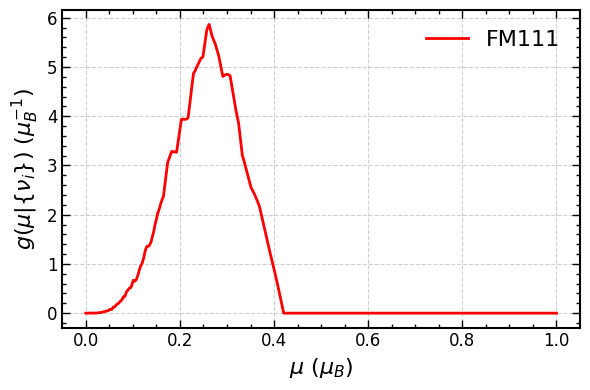

In [27]:
config_label = 'FM111'
print(f"Evaluating Bayesian Posterior [{config_label}]...")
estimator = BayesianMomentEstimator(loaded_BNOO_freqs[config_label])

posterior_FM111 = estimator.posterior(
    frequencies=expt_freqs,  
    errors=expt_freqs_err,            
    mu_grid=mu_grid
)

map_val = estimator.MAP(mu_grid, posterior_FM111)
ci_low, ci_high = estimator.credible_interval(mu_grid, posterior_FM111)


print("\n--- RESULTS ---")
print(f"MAP Moment: {map_val:.4f} \mu_B")
print(f"68% Credible Interval: [{ci_low:.4f}, {ci_high:.4f}] \mu_B")

# plot results
figsize=None
figsize=(6, 4)
fontsize=16
fig, ax = plt.subplots(figsize=figsize)

ax.plot(mu_grid, posterior_FM111, 'r-', lw=2, label=config_label)
ax.set_xlabel(r"$\mu$ ($\mu_B$)", fontsize=fontsize)
ax.set_ylabel(r"$g(\mu | \{\nu_i\})$ ($\mu_B^{-1}$)", fontsize=fontsize)
ax.grid(True, linestyle="--", alpha=0.6)

fancy_style_axes(ax)

ax.legend(frameon=False)
ax.legend(
    loc="best", 
    # bbox_to_anchor=(0.5, 1.001), 
    fontsize=fontsize,
    ncol=1, frameon=False, handlelength=1.9, columnspacing=1.2,
)


plt.tight_layout()
plt.show()

Evaluating Bayesian Posterior [AFM001]...

--- RESULTS ---
MAP Moment: 0.1141 \mu_B
68% Credible Interval: [0.0912, 0.1231] \mu_B


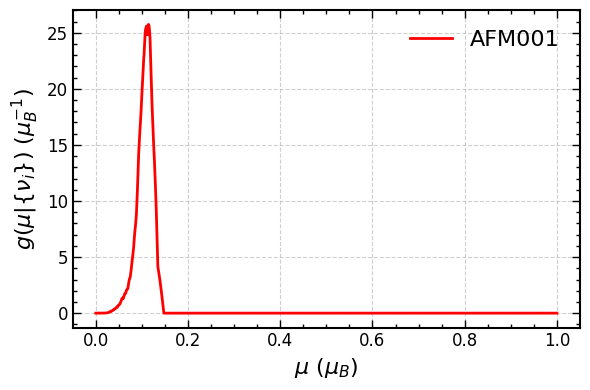

In [28]:
config_label = 'AFM001'
print(f"Evaluating Bayesian Posterior [{config_label}]...")
estimator = BayesianMomentEstimator(loaded_BNOO_freqs[config_label])

posterior_FM111 = estimator.posterior(
    frequencies=expt_freqs,  
    errors=expt_freqs_err,            
    mu_grid=mu_grid
)

map_val = estimator.MAP(mu_grid, posterior_FM111)
ci_low, ci_high = estimator.credible_interval(mu_grid, posterior_FM111)


print("\n--- RESULTS ---")
print(f"MAP Moment: {map_val:.4f} \mu_B")
print(f"68% Credible Interval: [{ci_low:.4f}, {ci_high:.4f}] \mu_B")

# plot results
figsize=None
figsize=(6, 4)
fontsize=16
fig, ax = plt.subplots(figsize=figsize)

ax.plot(mu_grid, posterior_FM111, 'r-', lw=2, label=config_label)
ax.set_xlabel(r"$\mu$ ($\mu_B$)", fontsize=fontsize)
ax.set_ylabel(r"$g(\mu | \{\nu_i\})$ ($\mu_B^{-1}$)", fontsize=fontsize)
ax.grid(True, linestyle="--", alpha=0.6)

fancy_style_axes(ax)

ax.legend(frameon=False)
ax.legend(
    loc="best", 
    # bbox_to_anchor=(0.5, 1.001), 
    fontsize=fontsize,
    ncol=1, frameon=False, handlelength=1.9, columnspacing=1.2,
)


plt.tight_layout()
plt.show()

In [29]:
class BayesianMomentEstimator:
    """
    Bayesian estimator for the magnetic moment.

    Works for either a single observed frequency or
    multiple observed frequencies.

    For frequencies {nu_i}:

        posterior(mu) ∝ Π_i L_i(mu)

    where

        L_i(mu) =
            ∫ f(nu'/mu) dnu'

    over the experimental uncertainty interval
    [nu_i - dnu_i, nu_i + dnu_i].
    """

    def __init__(
        self,
        nu_per_mu: np.ndarray,
        num_kde_points: int = 2000,
    ):
        self.nu_per_mu = np.asarray(
            nu_per_mu,
            dtype=float,
        )

        if self.nu_per_mu.ndim != 1:
            raise ValueError(
                "nu_per_mu must be a 1D array."
            )

        if len(self.nu_per_mu) < 2:
            raise ValueError(
                "nu_per_mu must contain at least two samples."
            )

        self.kde = gaussian_kde(
            self.nu_per_mu
        )

        self.x_grid = np.linspace(
            self.nu_per_mu.min() * 0.5,
            self.nu_per_mu.max() * 1.5,
            num_kde_points,
        )

        self.f_grid = self.kde(
            self.x_grid
        )

    def _f_val(self, x):
        """Evaluate f(nu/mu) using interpolation."""

        return np.interp(
            x,
            self.x_grid,
            self.f_grid,
            left=0.0,
            right=0.0,
        )

    def likelihood_single(
        self,
        nu: float,
        dnu: float,
        mu_grid: np.ndarray,
        n_points: int = 200,
    ):
        """
        Likelihood contribution from ONE observed frequency.

        Parameters
        ----------
        nu : float
            Observed frequency.

        dnu : float
            Experimental uncertainty.

        mu_grid : np.ndarray
            Magnetic-moment grid.

        Returns
        -------
        np.ndarray
            L(mu) evaluated on mu_grid.
        """

        mu_grid = np.asarray(
            mu_grid,
            dtype=float,
        )

        nu_points = np.linspace(
            nu - dnu,
            nu + dnu,
            n_points,
        )

        likelihood = np.zeros_like(
            mu_grid,
            dtype=float,
        )

        for i, mu in enumerate(mu_grid):

            if mu <= 0:
                continue

            likelihood[i] = simpson(
                self._f_val(
                    nu_points / mu
                ),
                x=nu_points,
            )

        return likelihood

    def posterior(
        self,
        frequencies,
        errors,
        mu_grid,
    ):
        """
        Calculate the posterior for one or more
        observed frequencies.

        A single frequency is also accepted.

        Examples
        --------
        Single frequency:

            frequencies = 3.9
            errors = 0.1

        Multiple frequencies:

            frequencies = [3.9, 1.56]
            errors = [0.1, 0.2]
        """

        # Convert scalars into one-element arrays.
        frequencies = np.atleast_1d(
            np.asarray(
                frequencies,
                dtype=float,
            )
        )

        errors = np.atleast_1d(
            np.asarray(
                errors,
                dtype=float,
            )
        )

        mu_grid = np.asarray(
            mu_grid,
            dtype=float,
        )

        if frequencies.shape != errors.shape:
            raise ValueError(
                "'frequencies' and 'errors' "
                "must have the same length."
            )

        if np.any(errors < 0):
            raise ValueError(
                "Frequency errors must be non-negative."
            )

        posterior = np.ones_like(
            mu_grid,
            dtype=float,
        )

        # Product of likelihoods.
        for nu, dnu in zip(
            frequencies,
            errors,
        ):

            likelihood = self.likelihood_single(
                nu=nu,
                dnu=dnu,
                mu_grid=mu_grid,
            )

            posterior *= likelihood

        # Normalize.
        normalization = simpson(
            posterior,
            x=mu_grid,
        )

        if normalization <= 0:
            raise ValueError(
                "Posterior normalization is zero."
            )

        posterior /= normalization

        return posterior

    @staticmethod
    def MAP(
        mu_grid,
        posterior,
    ):
        return float(
            mu_grid[
                np.argmax(posterior)
            ]
        )

    @staticmethod
    def credible_interval(
        mu_grid,
        posterior,
        confidence=0.68,
    ):
        """
        Equal-tail credible interval.
        """

        cdf = np.zeros_like(
            posterior,
            dtype=float,
        )

        cdf[1:] = np.cumsum(
            0.5
            * (
                posterior[1:]
                + posterior[:-1]
            )
            * np.diff(mu_grid)
        )

        if cdf[-1] > 0:
            cdf /= cdf[-1]

        lower = (1 - confidence) / 2
        upper = 1 - lower

        lo = np.interp(
            lower,
            cdf,
            mu_grid,
        )

        hi = np.interp(
            upper,
            cdf,
            mu_grid,
        )

        return float(lo), float(hi)

In [30]:
# # ----------------------------------------------------------------------
# # Calculate Bayesian posteriors
# # ----------------------------------------------------------------------

# posteriors = {}

# results = {}


# for config_label, values in frequency_distributions.items():

#     print(
#         f"\nEvaluating Bayesian posterior "
#         f"[{config_label}]..."
#     )

#     estimator = BayesianMomentEstimator(
#         values
#     )

#     posterior = estimator.posterior(
#         frequencies=expt_freqs,
#         errors=expt_freqs_err,
#         mu_grid=mu_grid,
#     )

#     posteriors[config_label] = posterior

#     map_val = estimator.MAP(
#         mu_grid,
#         posterior,
#     )

#     ci_low, ci_high = (
#         estimator.credible_interval(
#             mu_grid,
#             posterior,
#         )
#     )

#     results[config_label] = {
#         "MAP": map_val,
#         "CI_low": ci_low,
#         "CI_high": ci_high,
#     }

#     print(
#         f"MAP = {map_val:.4f} mu_B"
#     )

#     print(
#         f"68% CI = "
#         f"[{ci_low:.4f}, {ci_high:.4f}] mu_B"
#     )

In [31]:
# # ----------------------------------------------------------------------
# # Plot Bayesian posterior for all three configurations
# # ----------------------------------------------------------------------

# fig, ax = plt.subplots(
#     figsize=(7, 5)
# )

# for label, posterior in posteriors.items():

#     ax.plot(
#         mu_grid,
#         posterior,
#         lw=2,
#         label=label,
#     )

# ax.set_xlabel(
#     r"$\mu$ ($\mu_B$)",
#     fontsize=16,
# )

# ax.set_ylabel(
#     r"$g(\mu|\{\nu_i\})$ ($\mu_B^{-1}$)",
#     fontsize=16,
# )

# # The calculation uses the full 0-1 mu_B prior.
# # This only controls the displayed region.
# ax.set_xlim(
#     0.0,
#     0.8,
# )

# style_axes(
#     ax,
#     fontsize=12,
# )

# ax.legend(
#     frameon=False,
#     fontsize=12,
# )

# plt.tight_layout()
# plt.show()


# # %%
# # ----------------------------------------------------------------------
# # Print final results
# # ----------------------------------------------------------------------

# print("\n" + "=" * 60)
# print("BAYESIAN MOMENT RESULTS")
# print("=" * 60)

# for label, result in results.items():

#     print(
#         f"{label:8s} : "
#         f"MAP = {result['MAP']:.4f} mu_B, "
#         f"68% CI = "
#         f"[{result['CI_low']:.4f}, "
#         f"{result['CI_high']:.4f}] mu_B"
#     )